# Part 3: ML Model Training & Product-Level Discount System

## 🎯 Learning Objectives
- Train sentiment analysis model using TF-IDF + Logistic Regression
- Evaluate model performance
- **Aggregate sentiment at PRODUCT level**
- Create smart discount system using:
  - Product sentiment (% negative reviews)
  - Stock levels (overstocked = higher discount)
  - Sales velocity (slow sales = higher discount)
- Analyze business impact

## 🏢 Business Logic

**Individual Review** → Sentiment Score

**Product Aggregation** →
- % Negative reviews
- Average sentiment confidence
- Stock level
- Sales velocity

**Discount Formula** →
```
Discount = f(sentiment_score, stock_pressure, sales_velocity)
```

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print("✅ Libraries loaded")

✅ Libraries loaded


In [35]:
# Workshop Progress Tracker
notebooks = ["01 Extract", "02 Prepare", "03 Storage", "04 ML", "05 Deploy"]
current = 3  # This is notebook 04

print("="*70)
print("📊 WORKSHOP PROGRESS")
print("="*70)
for i, nb in enumerate(notebooks):
    if i < current:
        print(f"✅ {nb}")
    elif i == current:
        print(f"👉 {nb} ← YOU ARE HERE")
    else:
        print(f"⬜ {nb}")
print("="*70)

📊 WORKSHOP PROGRESS
✅ 01 Extract
✅ 02 Prepare
✅ 03 Storage
👉 04 ML ← YOU ARE HERE
⬜ 05 Deploy


## Step 1: Load Gold Dataset

We'll load the final enriched dataset from the Gold layer (created in Notebook 2).

In [36]:
# Load Gold dataset (enriched with stock and sales data)
df = pd.read_csv('../data/gold/final_dataset.csv')

print("📊 Gold Dataset Loaded")
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

📊 Gold Dataset Loaded
Total rows: 763
Columns: ['product_id', 'product_name', 'date', 'rating', 'review_text', 'avg_stock_level', 'avg_daily_sales', 'stock_to_sales_ratio', 'days_of_inventory', 'sentiment', 'review_text_clean']

First few rows:


,product_id,product_name,date,rating,review_text,avg_stock_level,avg_daily_sales,stock_to_sales_ratio,days_of_inventory,sentiment,review_text_clean
0,5,Lettuce,2025-10-27,5.0,perfect lettuce! great taste and very fresh.,114.808989,0.0,114.808989,114.808989,positive,perfect lettuce! great taste and very fresh.
1,2,Carrots,2025-11-02,2.0,the carrots was moldy when i opened it.,154.101124,0.0,154.101124,154.101124,negative,the carrots was moldy when i opened it.
2,3,Spinach,2025-11-07,5.0,"excellent quality, will buy again!",98.101124,NaN,NaN,NaN,positive,"excellent quality, will buy again!"
3,1,Potatoes,2025-12-30,4.0,"great potatoes, perfect for cooking!",197.111111,200.0,0.980652,0.980652,positive,"great potatoes, perfect for cooking!"
4,5,Lettuce,2026-01-05,5.0,delicious lettuce! my family loved them.,114.808989,0.0,114.808989,114.808989,positive,delicious lettuce! my family loved them.


## Step 2: Split Data (Train/Test)

**Why split the data?**
- **Training set (80%)**: Used to train the model
- **Test set (20%)**: Used to evaluate performance on unseen data
- Prevents overfitting and gives realistic performance estimates

In [37]:
# Features (X) and target (y)
X = df['review_text_clean']
y = df['sentiment']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} reviews")
print(f"Test set: {len(X_test)} reviews")
print(f"\nTraining set sentiment distribution:")
print(y_train.value_counts())

Training set: 610 reviews
Test set: 153 reviews

Training set sentiment distribution:
sentiment
positive    376
neutral     152
negative     82
Name: count, dtype: int64


## Step 3: Text Vectorization (TF-IDF)

**What is TF-IDF?**
- **TF (Term Frequency)**: How often a word appears in a document
- **IDF (Inverse Document Frequency)**: How unique/important a word is across all documents
- Converts text into numerical features for ML

Example:
- "best" appears often in positive reviews → high TF-IDF for positive sentiment
- "worst" appears often in negative reviews → high TF-IDF for negative sentiment
- Common words like "the", "is" → low TF-IDF (not discriminative)

In [38]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=500,  # Use top 500 most important words
    min_df=2,  # Word must appear in at least 2 documents
    max_df=0.9,  # Ignore words that appear in >90% of documents
    ngram_range=(1, 2)  # Use single words and two-word phrases
)

# Fit on training data and transform both train and test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features (words/phrases): {len(vectorizer.get_feature_names_out())}")
print(f"\nTop 20 features:")
print(vectorizer.get_feature_names_out()[:20])

TF-IDF feature shape: (610, 332)
Number of features (words/phrases): 332

Top 20 features:
['about' 'again' 'all' 'all very' 'alright' 'alright nothing' 'always'
 'always consistent' 'amazing' 'amazing quality' 'and' 'and disappointing'
 'and tasteless' 'and tasty' 'and very' 'are' 'are alright' 'are okay'
 'are so' 'at']


## Step 4: Train Sentiment Analysis Model

We'll use **Logistic Regression** - a simple but effective classifier for text.

**How it works:**
- Learns weights for each word/phrase
- Positive words ("best", "fresh") → positive weight
- Negative words ("worst", "stale") → negative weight
- Combines weights to predict sentiment

In [39]:
# Train Logistic Regression classifier
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

print("Training model...")
model.fit(X_train_tfidf, y_train)
print("Model trained successfully!")

Training model...
Model trained successfully!


## Step 5: Evaluate Model Performance

### Analyze Output Model
How well does our sentiment classifier perform?

In [40]:
# Make predictions on test set
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        21
     neutral       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        94

    accuracy                           1.00       153
   macro avg       1.00      1.00      1.00       153
weighted avg       1.00      1.00      1.00       153



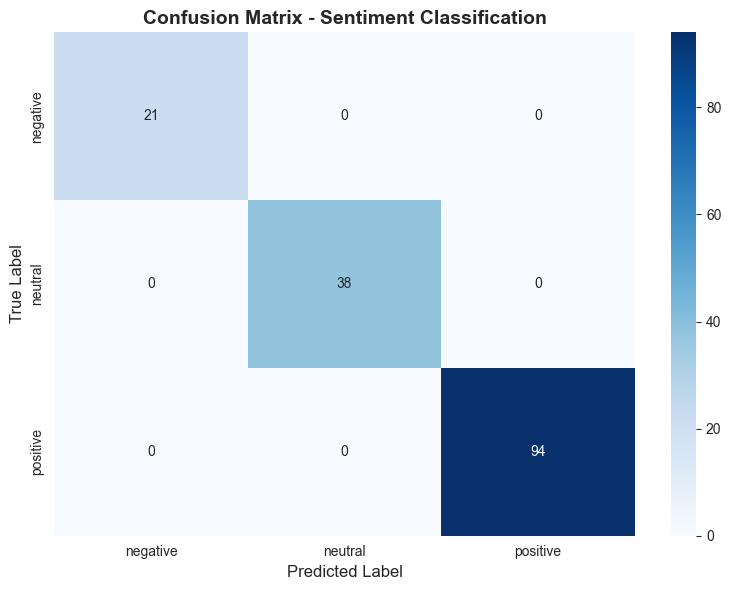


Confusion Matrix Interpretation:
- Diagonal values (correct predictions): Higher is better
- Off-diagonal values (mistakes): Lower is better


In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Diagonal values (correct predictions): Higher is better")
print("- Off-diagonal values (mistakes): Lower is better")

## Step 6: Analyze "Why" - Most Important Words

Let's see which words are most predictive for each sentiment.

In [42]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get class labels and coefficients
classes = model.classes_
coefficients = model.coef_

# Show top words for each sentiment
n_top = 10

for i, sentiment in enumerate(classes):
    print(f"\n{'='*60}")
    print(f"Top {n_top} words for '{sentiment.upper()}' sentiment:")
    print(f"{'='*60}")
    
    # Get indices of top features
    top_indices = coefficients[i].argsort()[-n_top:][::-1]
    
    for idx in top_indices:
        word = feature_names[idx]
        weight = coefficients[i][idx]
        print(f"  {word:20s} (weight: {weight:+.3f})")


Top 10 words for 'NEGATIVE' sentiment:
  was                  (weight: +1.066)
  disappointing        (weight: +1.025)
  very disappointed    (weight: +1.019)
  disappointed         (weight: +1.019)
  disappointed with    (weight: +1.019)
  with these           (weight: +1.019)
  with                 (weight: +1.019)
  ever                 (weight: +0.968)
  ever bought          (weight: +0.968)
  ve ever              (weight: +0.968)

Top 10 words for 'NEUTRAL' sentiment:
  fair                 (weight: +1.754)
  fair quality         (weight: +1.754)
  meets expectations   (weight: +1.434)
  meets                (weight: +1.434)
  standard             (weight: +1.434)
  but                  (weight: +1.341)
  ve had               (weight: +1.245)
  better               (weight: +1.245)
  had better           (weight: +1.245)
  nothing              (weight: +1.169)

Top 10 words for 'POSITIVE' sentiment:
  my                   (weight: +1.222)
  fresh                (weight: +1.088)
 

### 🔍 OPTIONAL CHALLENGE: Become a Model Detective!

**For Advanced Students:** Can you fool the model?

In [43]:
# Optional challenge for advanced students
print("="*70)
print("🔍 OPTIONAL CHALLENGE: Become a Model Detective!")
print("="*70)
print("\n🎯 CHALLENGE: Can you fool the model?")
print("\nTask: Write a review that SOUNDS positive but gets classified as negative")
print("(or vice versa)")
print("\nExample: 'This spinach is not bad' ← sounds neutral but might confuse model")
print("\n💡 Bonus points if you can explain WHY the model got confused!")
print("\nTry it in the prediction cell above, then discuss with neighbors.")
print("-"*70)
print("\n🤔 Think about:")
print("   • Negations: 'not bad' vs 'good'")
print("   • Sarcasm: 'Oh great, another stale carrot'")
print("   • Mixed signals: 'Fresh but tasteless'")
print("\n⏰ This is optional - skip if short on time!")

🔍 OPTIONAL CHALLENGE: Become a Model Detective!

🎯 CHALLENGE: Can you fool the model?

Task: Write a review that SOUNDS positive but gets classified as negative
(or vice versa)

Example: 'This spinach is not bad' ← sounds neutral but might confuse model

💡 Bonus points if you can explain WHY the model got confused!

Try it in the prediction cell above, then discuss with neighbors.
----------------------------------------------------------------------

🤔 Think about:
   • Negations: 'not bad' vs 'good'
   • Sarcasm: 'Oh great, another stale carrot'
   • Mixed signals: 'Fresh but tasteless'

⏰ This is optional - skip if short on time!


## Step 7: Make Predictions on New Reviews

Let's test our model with some example reviews.

In [44]:
def predict_sentiment(review_text):
    """
    Predict sentiment for a review text
    """
    # Preprocess text (same as training)
    import re
    text_clean = review_text.lower()
    text_clean = ' '.join(text_clean.split())
    text_clean = re.sub(r'[^a-z\s.,!?]', '', text_clean)
    
    # Vectorize
    text_tfidf = vectorizer.transform([text_clean])
    
    # Predict
    sentiment = model.predict(text_tfidf)[0]
    probabilities = model.predict_proba(text_tfidf)[0]
    
    return sentiment, probabilities

# Test with example reviews
test_reviews = [
    "This is the worst spinach ever! Not fresh at all.",
    "Best potatoes in my life! Super fresh and delicious.",
    "The carrot was a bit stale and disappointing.",
    "These tomatoes are okay, nothing special."
]

print("Test Predictions:")
print("="*80)

for review in test_reviews:
    sentiment, probs = predict_sentiment(review)
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sentiment.upper()}")
    print(f"Confidence: {probs.max():.1%}")
    print(f"Probabilities: Negative={probs[0]:.2%}, Neutral={probs[1]:.2%}, Positive={probs[2]:.2%}")

Test Predictions:

Review: This is the worst spinach ever! Not fresh at all.
Predicted Sentiment: NEGATIVE
Confidence: 89.9%
Probabilities: Negative=89.92%, Neutral=5.15%, Positive=4.93%

Review: Best potatoes in my life! Super fresh and delicious.
Predicted Sentiment: POSITIVE
Confidence: 94.1%
Probabilities: Negative=3.24%, Neutral=2.65%, Positive=94.11%

Review: The carrot was a bit stale and disappointing.
Predicted Sentiment: NEGATIVE
Confidence: 89.8%
Probabilities: Negative=89.84%, Neutral=4.11%, Positive=6.06%

Review: These tomatoes are okay, nothing special.
Predicted Sentiment: NEUTRAL
Confidence: 82.0%
Probabilities: Negative=6.50%, Neutral=81.99%, Positive=11.51%


**💡 Group Challenge:** Who can write a review that gets a 90% discount? Try it and discuss with your neighbor - why did certain words trigger such a high discount?

### 🎮 YOUR TURN: Interactive Prediction Station!

Now it's your turn to test the model! Try typing your own product reviews and see what happens.

In [45]:
# Interactive prediction cell
print("="*70)
print("🎮 YOUR TURN: Test the Sentiment Analysis Model!")
print("="*70)
print("\nModify the review below and re-run this cell to test different reviews!")
print("Tip: Try being very positive or very negative to see extreme results\n")

# ✏️ EDIT THIS: Change the review text and re-run the cell!
user_review = "This is the worst spinach ever! Not fresh at all."

# Predict sentiment
sentiment, probs = predict_sentiment(user_review)
confidence = probs.max()

# Fun emoji based on sentiment
emoji = {'positive': '😊', 'neutral': '😐', 'negative': '😠'}[sentiment]

print("-"*70)
print(f"📝 Your Review: \"{user_review}\"")
print(f"\n   {emoji} Sentiment: {sentiment.upper()}")
print(f"   📊 Confidence: {confidence:.0%}")
print(f"   💰 Probabilities:")
print(f"      Negative: {probs[0]:.1%} | Neutral: {probs[1]:.1%} | Positive: {probs[2]:.1%}")

# Calculate discount
if sentiment == 'negative':
    discount = 70 + int((confidence - 0.6) * 50) if confidence >= 0.6 else 50
elif sentiment == 'neutral':
    discount = 25
else:
    discount = 5
discount = min(discount, 90)

print(f"   🎯 Recommended Discount: {discount}%")

if discount >= 70:
    print(f"   💥 WOW! That's a major discount! Product needs attention!")
elif discount <= 10:
    print(f"   ✨ Great review! Product is selling itself!")

print("="*70)
print("\n💡 TIP: Edit the 'user_review' text above and re-run this cell!")
print("\nTry these examples:")
print("  • 'Best potatoes in my life! Super fresh and delicious.'")
print("  • 'The carrot was okay, nothing special'")
print("  • 'Terrible quality, very disappointed with these tomatoes'")

🎮 YOUR TURN: Test the Sentiment Analysis Model!

Modify the review below and re-run this cell to test different reviews!
Tip: Try being very positive or very negative to see extreme results

----------------------------------------------------------------------
📝 Your Review: "This is the worst spinach ever! Not fresh at all."

   😠 Sentiment: NEGATIVE
   📊 Confidence: 90%
   💰 Probabilities:
      Negative: 89.9% | Neutral: 5.1% | Positive: 4.9%
   🎯 Recommended Discount: 84%
   💥 WOW! That's a major discount! Product needs attention!

💡 TIP: Edit the 'user_review' text above and re-run this cell!

Try these examples:
  • 'Best potatoes in my life! Super fresh and delicious.'
  • 'The carrot was okay, nothing special'
  • 'Terrible quality, very disappointed with these tomatoes'


## Step 8: Discount Recommendation System

Now let's create the discount recommendation logic!

### Discount Rules:
- **Negative sentiment (1-2 stars)**: 50-90% discount
- **Neutral sentiment (3 stars)**: 20-30% discount
- **Positive sentiment (4-5 stars)**: 0-10% discount

We'll also consider:
- Confidence of the prediction (higher confidence → more extreme discount)
- Sales volume (lower sales + negative sentiment → higher discount)

**💬 Group Discussion (2 minutes):**
- Which product would you focus on first as a store manager?
- Why might certain products have more negative reviews? (Think: perishability, freshness, storage)

In [46]:
# Create a fun leaderboard
print("="*70)
print("🏆 PRODUCT SENTIMENT LEADERBOARD 🏆")
print("="*70)

# Calculate sentiment scores (weighted)
product_stats_lb = df.groupby('product_name').agg({
    'sentiment': [
        ('negative_pct', lambda x: (x == 'negative').mean() * 100),
        ('positive_pct', lambda x: (x == 'positive').mean() * 100),
        ('total_reviews', 'count')
    ],
    'rating': 'mean'
}).round(1)

# Flatten columns
product_stats_lb.columns = ['_'.join(col) for col in product_stats_lb.columns]
product_stats_lb = product_stats_lb.reset_index()

# Create overall score (0-100, higher is better)
product_stats_lb['happiness_score'] = (
    product_stats_lb['sentiment_positive_pct'] -
    product_stats_lb['sentiment_negative_pct']
)

# Sort and rank
product_stats_lb = product_stats_lb.sort_values('happiness_score', ascending=False)
product_stats_lb['rank'] = range(1, len(product_stats_lb) + 1)

# Display with fun formatting
print("\n🥇 HAPPIEST PRODUCTS (Customer Loves Them)")
print("-"*70)
for _, row in product_stats_lb.head(3).iterrows():
    emoji = "🥇" if row['rank'] == 1 else "🥈" if row['rank'] == 2 else "🥉"
    print(f"{emoji} #{int(row['rank'])} {row['product_name']:15} | "
          f"Happiness Score: {row['happiness_score']:+.1f} | "
          f"⭐ {row['rating_mean']:.1f}/5.0")

print("\n\n😰 NEEDS ATTENTION (High Negative Sentiment)")
print("-"*70)
for _, row in product_stats_lb.tail(3).iterrows():
    print(f"⚠️  #{int(row['rank'])} {row['product_name']:15} | "
          f"Happiness Score: {row['happiness_score']:+.1f} | "
          f"❌ {row['sentiment_negative_pct']:.1f}% negative")

print("\n💡 BUSINESS INSIGHT: Which products need discount campaigns?")

🏆 PRODUCT SENTIMENT LEADERBOARD 🏆

🥇 HAPPIEST PRODUCTS (Customer Loves Them)
----------------------------------------------------------------------
🥇 #1 Broccoli        | Happiness Score: +54.5 | ⭐ 3.8/5.0
🥈 #2 Potatoes        | Happiness Score: +51.3 | ⭐ 3.7/5.0
🥉 #3 Spinach         | Happiness Score: +51.0 | ⭐ 3.8/5.0


😰 NEEDS ATTENTION (High Negative Sentiment)
----------------------------------------------------------------------
⚠️  #4 Tomatoes        | Happiness Score: +46.9 | ❌ 11.7% negative
⚠️  #5 Carrots         | Happiness Score: +44.0 | ❌ 19.3% negative
⚠️  #6 Lettuce         | Happiness Score: +39.6 | ❌ 14.7% negative

💡 BUSINESS INSIGHT: Which products need discount campaigns?


---

# Part D: MLOps Basics - Model Versioning & Validation

## 🎯 Before Deployment, We Need:
1. **Model Versioning** - Track which model is in production
2. **Model Registry** - Store model metadata
3. **Validation Checks** - Ensure model quality before deployment

Let's add these professional practices!

## Step 1: Save Model with Versioning

Instead of just saving the model, we save it with **version metadata**.

In [57]:
import json
from datetime import datetime

# Create version metadata
model_version = {
    "version": "1.0.0",
    "timestamp": datetime.now().isoformat(),
    "accuracy": float(accuracy),
    "precision": float(precision_score(y_test, y_pred, average='weighted')),
    "recall": float(recall_score(y_test, y_pred, average='weighted')),
    "f1_score": float(f1_score(y_test, y_pred, average='weighted')),
    "hyperparameters": {
        "C": 1.0,
        "max_iter": 100,
        "solver": "lbfgs"
    },
    "training_samples": len(X_train),
    "test_samples": len(X_test)
}

# Save model with version in filename
model_filename = f'sentiment_model_v{model_version["version"]}.pkl'
with open(f'../models/{model_filename}', 'wb') as f:
    pickle.dump(model, f)

# Save metadata as JSON
metadata_filename = f'sentiment_model_v{model_version["version"]}_metadata.json'
with open(f'../models/{metadata_filename}', 'w') as f:
    json.dump(model_version, f, indent=2)

# Save vectorizer (THIS WAS MISSING!)
vectorizer_filename = f'tfidf_vectorizer.pkl'
with open(f'../models/{vectorizer_filename}', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✅ Model v{model_version['version']} saved with metadata")
print(f"📁 Model: ../models/{model_filename}")
print(f"📄 Metadata: ../models/{metadata_filename}")
print(f"📄 Vectorizer: ../models/{vectorizer_filename}")
print("\n📊 Metadata:")
print(json.dumps(model_version, indent=2))

✅ Model v1.0.0 saved with metadata
📁 Model: ../models/sentiment_model_v1.0.0.pkl
📄 Metadata: ../models/sentiment_model_v1.0.0_metadata.json
📄 Vectorizer: ../models/tfidf_vectorizer.pkl

📊 Metadata:
{
  "version": "1.0.0",
  "timestamp": "2026-01-13T14:31:15.816854",
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1_score": 1.0,
  "hyperparameters": {
    "C": 1.0,
    "max_iter": 100,
    "solver": "lbfgs"
  },
  "training_samples": 610,
  "test_samples": 153
}


## Step 2: Simple Model Registry (Mock)

A **model registry** tracks all model versions and their status (staging, production, archived).

In production, this would be **Azure ML Model Registry** or **MLflow**. Here, we use a simple Python dictionary as a demonstration.

In [52]:
# Mock model registry
MODEL_REGISTRY = {
    "sentiment_classifier": {
        "versions": {
            "1.0.0": {
                "status": "production",
                "accuracy": model_version["accuracy"],
                "deployed_date": model_version["timestamp"],
                "path": f"../models/{model_filename}"
            },
            "0.9.0": {
                "status": "archived",
                "accuracy": 0.82,
                "deployed_date": "2024-12-01T10:00:00",
                "path": "../models/sentiment_model_v0.9.0.pkl"
            }
        },
        "production_version": "1.0.0"
    }
}

def get_production_model(model_name):
    """Load production model from registry"""
    registry_entry = MODEL_REGISTRY[model_name]
    prod_version = registry_entry["production_version"]
    model_path = registry_entry["versions"][prod_version]["path"]
    
    with open(model_path, 'rb') as f:
        return pickle.load(f), prod_version

def list_model_versions(model_name):
    """List all versions of a model"""
    registry_entry = MODEL_REGISTRY[model_name]
    print(f"\n📦 MODEL REGISTRY: {model_name}")
    print("=" * 70)
    print(f"Production Version: {registry_entry['production_version']}")
    print("\nAll Versions:")
    for version, info in registry_entry["versions"].items():
        status_emoji = "🟢" if info["status"] == "production" else "⚪"
        print(f"  {status_emoji} v{version}: {info['status']} | Accuracy: {info['accuracy']:.2%} | Deployed: {info['deployed_date'][:10]}")
    print("=" * 70)

# Demo: List versions
list_model_versions("sentiment_classifier")

# Demo: Load production model
prod_model, version = get_production_model("sentiment_classifier")
print(f"\n✅ Loaded production model: v{version}")


📦 MODEL REGISTRY: sentiment_classifier
Production Version: 1.0.0

All Versions:
  🟢 v1.0.0: production | Accuracy: 100.00% | Deployed: 2026-01-13
  ⚪ v0.9.0: archived | Accuracy: 82.00% | Deployed: 2024-12-01

✅ Loaded production model: v1.0.0


## Step 3: Model Validation Checks

Before deploying, we run **automated validation checks** to ensure quality.

### Deployment Criteria:
1. ✅ Accuracy >= 80%
2. ✅ All classes have recall >= 70% (balanced performance)
3. ✅ Model size < 50 MB (deployment efficiency)

In [54]:
import sys
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

def validate_model_for_deployment(model, vectorizer, X_test, y_test, min_accuracy=0.80, min_recall=0.70, max_size_mb=50):
    """
    Validate model against deployment criteria.
    
    Returns:
        bool: True if model passes all checks, False otherwise
    """
    
    checks = {
        "passed": [],
        "failed": []
    }
    
    # Transform test data
    X_test_tfidf = vectorizer.transform(X_test)
    y_pred = model.predict(X_test_tfidf)
    
    # Check 1: Minimum accuracy
    test_accuracy = accuracy_score(y_test, y_pred)
    if test_accuracy >= min_accuracy:
        checks["passed"].append(f"✅ Accuracy: {test_accuracy:.2%} (>= {min_accuracy:.0%})")
    else:
        checks["failed"].append(f"❌ Accuracy: {test_accuracy:.2%} (< {min_accuracy:.0%})")
    
    # Check 2: Balanced performance across classes
    report = classification_report(y_test, y_pred, output_dict=True)
    class_recalls = {label: report[label]['recall'] for label in ['negative', 'neutral', 'positive']}
    min_class_recall = min(class_recalls.values())
    worst_class = [label for label, recall in class_recalls.items() if recall == min_class_recall][0]
    
    if min_class_recall >= min_recall:
        checks["passed"].append(f"✅ Min class recall ({worst_class}): {min_class_recall:.2%} (>= {min_recall:.0%})")
    else:
        checks["failed"].append(f"❌ Min class recall ({worst_class}): {min_class_recall:.2%} (< {min_recall:.0%})")
    
    # Check 3: Model size
    model_size_mb = sys.getsizeof(pickle.dumps(model)) / (1024 * 1024)
    vectorizer_size_mb = sys.getsizeof(pickle.dumps(vectorizer)) / (1024 * 1024)
    total_size_mb = model_size_mb + vectorizer_size_mb
    
    if total_size_mb < max_size_mb:
        checks["passed"].append(f"✅ Total model size: {total_size_mb:.2f} MB (< {max_size_mb} MB)")
    else:
        checks["failed"].append(f"❌ Total model size: {total_size_mb:.2f} MB (>= {max_size_mb} MB)")
    
    # Decision
    can_deploy = len(checks["failed"]) == 0
    
    # Print report
    print("\n🔍 MODEL VALIDATION REPORT")
    print("=" * 70)
    print("\n✅ PASSED CHECKS:")
    for check in checks["passed"]:
        print(f"  {check}")
    
    if checks["failed"]:
        print("\n❌ FAILED CHECKS:")
        for check in checks["failed"]:
            print(f"  {check}")
    
    print("\n" + "=" * 70)
    
    if can_deploy:
        print("🚀 DECISION: Model APPROVED for deployment")
    else:
        print("🛑 DECISION: Model REJECTED - Fix issues before deployment")
    
    print("=" * 70)
    
    return can_deploy

# Run validation
can_deploy = validate_model_for_deployment(model, vectorizer, X_test, y_test)

if can_deploy:
    print("\n✅ Model ready for deployment to production!")
    print("📦 Next step: Deploy via API (see next notebook)")
else:
    print("\n⚠️  Model needs improvement before deployment.")
    print("💡 Suggestions: Collect more data, tune hyperparameters, or try different algorithms.")


🔍 MODEL VALIDATION REPORT

✅ PASSED CHECKS:
  ✅ Accuracy: 100.00% (>= 80%)
  ✅ Min class recall (negative): 100.00% (>= 70%)
  ✅ Total model size: 0.02 MB (< 50 MB)

🚀 DECISION: Model APPROVED for deployment

✅ Model ready for deployment to production!
📦 Next step: Deploy via API (see next notebook)


## Step 9: Analyze All Products

Let's see which products need the most discounts based on their reviews.

## 💡 Key Takeaways: MLOps Basics

### What We Just Did:

1. **Model Versioning** 📦
   - Saved model with version number (v1.0.0)
   - Stored metadata (accuracy, precision, hyperparameters)
   - Can track multiple versions over time

2. **Model Registry** 📋
   - Centralized tracking of all models
   - Know which version is in production
   - Easy rollback if new version fails

3. **Model Validation** ✅
   - Automated checks before deployment
   - Prevent bad models from reaching production
   - Quality gates (accuracy, balance, size)

### In Production (Albert Heijn):

| What We Did | Real Production Tool |
|-------------|---------------------|
| Python dict registry | **Azure ML Model Registry** or **MLflow** |
| Manual validation | **CI/CD pipeline** (automated) |
| Local files | **Azure Blob Storage** (centralized) |
| JSON metadata | **Database** with full lineage tracking |

### Why This Matters:

- 🚀 **Faster debugging**: "Which model version is in production?"
- 🔒 **Safety**: Bad models can't deploy automatically
- 📊 **Tracking**: Compare model versions over time
- 🔄 **Rollback**: Revert to previous version if issues arise

---

## 🚀 Next: Deployment Practice

Now that our model is validated and versioned, let's deploy it as an API!

**Next notebook**: `05_deployment_practice.ipynb`